# GTJA 191 Alpha Factors — GP Discovery Pipeline (Standalone)

Self-contained notebook: **OpenBB + Yahoo Finance** (HK-friendly) → **GP** → 191 alphas.

```text
~60 A-shares → panel → GP evolve → hall-of-fame → decorrelate → 191 alphas
```

**Run:** Kernel → Restart & Run All (~15–25 min with 60 stocks).


In [1]:
%pip install -q openbb openbb-yfinance pandas numpy matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [14]:
import random
import warnings
import time
from dataclasses import dataclass
from typing import Any
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw): return x

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

random.seed(42)
np.random.seed(42)

# ── Universe (~60 liquid A-shares, Yahoo-compatible) ──
SYMBOLS = ['600519', '601318', '600036', '601166', '600900', '600030', '601012', '600276', '601888', '600000', '601398', '601288', '601939', '601328', '600887', '603259', '601857', '600309', '601668', '600690', '601601', '600809', '601988', '600048', '601628', '600585', '601818', '600104', '601688', '600031', '601766', '600050', '601390', '600196', '601225', '600741', '601127', '600660', '601336', '600406', '000858', '000333', '300750', '002594', '300059', '000001', '000002', '000725', '002415', '000568', '002304', '300015', '000063', '002352', '300124', '000651', '002142', '300274', '000776', '002230', '300498', '000538', '002460', '300014']
MIN_LOADED = 40          # min tickers required from OpenBB

# ── GP knobs (tuned for ~60 stocks) ──
TARGET_N = 191
POP_SIZE = 60
GENERATIONS = 12
MAX_DEPTH = 4
CROSSOVER_RATE = 0.7
MUTATION_RATE = 0.35
TOURNAMENT_K = 3
ELITE_N = 6
HALL_OF_FAME = 500
CORR_THRESH = 0.65       # stricter decorrelation
MIN_IC_DAYS = 30
MIN_CS_NAMES = 20        # min stocks per day for IC
MAX_ZERO_FRAC = 0.25    # reject degenerate factors

START, END = "2023-01-01", "2024-06-30"
TRAIN_END = "2024-01-01"   # GP + selection use dates <= this
TEST_START = "2024-01-01"  # OOS evaluation uses dates >= this
FWD_HORIZON = 5

# OOS filters for "effective" factors
OOS_MIN_DAYS = 15
OOS_MIN_IR = 0.10
OOS_MIN_IC = 0.0
OOS_IR_DECAY_MIN = 0.40   # oos_ir / is_ir must exceed this
WINDOWS = (3, 5, 6, 8, 10, 15, 20)

DATA_PROVIDER = "openbb"       # "openbb" | "synthetic"
OPENBB_PROVIDER = "yfinance"
FETCH_SLEEP = 0.15


In [3]:
# ── Panel utilities & operators ──

def safe_div(num, den):
    return (num / den.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)


def derive_fields(panel):
    out = dict(panel)
    if "vwap" not in out:
        out["vwap"] = safe_div(out["amount"], out["volume"]) if "amount" in out else (out["high"] + out["low"] + out["close"]) / 3.0
    if "ret" not in out:
        out["ret"] = out["close"].pct_change()
    out["range_pct"] = safe_div(out["high"] - out["low"], out["close"])
    out["body_pct"] = safe_div(out["close"] - out["open"], out["open"])
    out["pressure"] = safe_div((out["close"] - out["low"]) - (out["high"] - out["close"]), out["high"] - out["low"])
    return out


def align_panels(panels):
    idx = cols = None
    for df in panels.values():
        idx = df.index if idx is None else idx.union(df.index)
        cols = df.columns if cols is None else cols.union(df.columns)
    return {k: v.reindex(index=idx.sort_values(), columns=cols.sort_values()) for k, v in panels.items()}


def ts_delta(x, n=1): return x - x.shift(n)
def ts_delay(x, n=1): return x.shift(n)
def ts_sum(x, n): return x.rolling(n, min_periods=n).sum()
def ts_mean(x, n): return x.rolling(n, min_periods=n).mean()
def ts_std(x, n): return x.rolling(n, min_periods=n).std()
def ts_max(x, n): return x.rolling(n, min_periods=n).max()
def ts_min(x, n): return x.rolling(n, min_periods=n).min()
def ts_corr(a, b, n): return a.rolling(n, min_periods=n).corr(b)
def ts_log(x): return np.log(x.replace(0, np.nan))
def cs_rank(x): return x.rank(axis=1, pct=True, method="average")
def cs_scale(x): return x.div(x.abs().sum(axis=1).replace(0, np.nan), axis=0)


def ts_rank(x, n):
    def _last(w):
        s = pd.Series(w)
        return s.rank(pct=True).iloc[-1] if not s.isna().all() else np.nan
    return x.rolling(n, min_periods=n).apply(_last, raw=False)


TS_UNARY = {
    "delta": lambda x, w: ts_delta(x, w),
    "delay": lambda x, w: ts_delay(x, w),
    "mean": lambda x, w: ts_mean(x, w),
    "std": lambda x, w: ts_std(x, w),
    "sum": lambda x, w: ts_sum(x, w),
    "max": lambda x, w: ts_max(x, w),
    "min": lambda x, w: ts_min(x, w),
    "tsrank": lambda x, w: ts_rank(x, w),
}


In [4]:
# ── Data loaders: OpenBB (Yahoo) + synthetic fallback ──

def to_yahoo_symbol(code: str) -> str:
    code = str(code).zfill(6)
    return f"{code}.SS" if code.startswith("6") else f"{code}.SZ"


def make_synthetic_panel(tickers, start, end, seed=42):
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start, end)
    closes = [pd.Series(10 * np.exp(np.cumsum(rng.normal(0.0005, 0.02, len(dates)))), index=dates) for _ in tickers]
    close_df = pd.concat(closes, axis=1)
    close_df.columns = tickers
    shape = close_df.shape
    high_df = close_df * (1 + rng.uniform(0.001, 0.02, shape))
    low_df = close_df * (1 - rng.uniform(0.001, 0.02, shape))
    open_df = close_df.shift(1).fillna(close_df.iloc[0]) * (1 + rng.normal(0, 0.005, shape))
    vol_df = pd.DataFrame(rng.integers(1_000_000, 5_000_000, shape), index=dates, columns=tickers, dtype=float)
    return align_panels({
        "open": open_df, "high": high_df, "low": low_df, "close": close_df,
        "volume": vol_df, "amount": vol_df * close_df,
    })


def _normalize_ohlcv(df, local_code):
    out = df.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        out.index = pd.to_datetime(out.get("date", out.index))
    out.index = out.index.tz_localize(None) if getattr(out.index, "tz", None) else out.index
    out = out.sort_index()
    out = out.rename(columns={c: c.lower() for c in out.columns})
    need = ["open", "high", "low", "close", "volume"]
    if any(c not in out.columns for c in need):
        raise ValueError(f"{local_code}: missing OHLCV columns")
    if "amount" not in out.columns:
        out["amount"] = out["close"] * out["volume"]
    return out[need + ["amount"]]


def load_openbb_panel(symbols, start, end, provider=OPENBB_PROVIDER, sleep_sec=FETCH_SLEEP, min_loaded=MIN_LOADED):
    from openbb import obb

    buckets = {k: [] for k in ("open", "high", "low", "close", "volume", "amount")}
    failed = []

    for sym in tqdm(symbols, desc="OpenBB fetch"):
        ysym = to_yahoo_symbol(sym)
        try:
            result = obb.equity.price.historical(symbol=ysym, start_date=start, end_date=end, provider=provider)
            df = _normalize_ohlcv(result.to_dataframe(), sym)
            for field in buckets:
                buckets[field].append(df[field].rename(sym))
        except Exception as exc:
            failed.append((sym, str(exc)[:80]))
        time.sleep(sleep_sec)

    n_ok = len(buckets["close"])
    print(f"Loaded {n_ok}/{len(symbols)} tickers" + (f"  ({len(failed)} failed)" if failed else ""))
    min_required = min(min_loaded, max(30, int(len(symbols) * 0.75)))
    if n_ok < min_required:
        raise RuntimeError(f"Only {n_ok} tickers loaded (need ≥{min_required}). Try DATA_PROVIDER='synthetic'.")
    return align_panels({k: pd.concat(v, axis=1) for k, v in buckets.items()})


def load_panel(symbols, start, end, provider=DATA_PROVIDER):
    if provider == "openbb":
        try:
            return load_openbb_panel(symbols, start, end), f"openbb/{OPENBB_PROVIDER}"
        except Exception as exc:
            print(f"OpenBB failed: {exc}")
            print("→ falling back to synthetic panel")
    return make_synthetic_panel(symbols, start, end), "synthetic"


In [5]:
# ── Expression grammar + Genetic Programming ──

@dataclass(frozen=True)
class Expr:
    op: str
    args: tuple[Any, ...] = ()
    def __repr__(self):
        return expr_str(self)


def expr_str(e):
    if e.op == "field": return e.args[0]
    if e.op == "neg": return f"-({expr_str(e.args[0])})"
    if e.op == "log": return f"log({expr_str(e.args[0])})"
    if e.op == "rank": return f"rank({expr_str(e.args[0])})"
    if e.op == "scale": return f"scale({expr_str(e.args[0])})"
    if e.op in TS_UNARY: return f"{e.op}({expr_str(e.args[0])},{e.args[1]})"
    if e.op == "corr": return f"corr({expr_str(e.args[0])},{expr_str(e.args[1])},{e.args[2]})"
    if e.op == "mul": return f"({expr_str(e.args[0])}*{expr_str(e.args[1])})"
    if e.op == "sub": return f"({expr_str(e.args[0])}-{expr_str(e.args[1])})"
    return str(e.op)


def eval_expr(e, f):
    if e.op == "field": return f[e.args[0]]
    if e.op == "neg": return -eval_expr(e.args[0], f)
    if e.op == "log": return ts_log(eval_expr(e.args[0], f))
    if e.op == "rank": return cs_rank(eval_expr(e.args[0], f))
    if e.op == "scale": return cs_scale(eval_expr(e.args[0], f))
    if e.op in TS_UNARY: return TS_UNARY[e.op](eval_expr(e.args[0], f), e.args[1])
    if e.op == "corr": return ts_corr(eval_expr(e.args[0], f), eval_expr(e.args[1], f), e.args[2])
    if e.op == "mul": return eval_expr(e.args[0], f) * eval_expr(e.args[1], f)
    if e.op == "sub": return eval_expr(e.args[0], f) - eval_expr(e.args[1], f)
    raise ValueError(e.op)


BASE_FIELDS = ["open", "high", "low", "close", "volume", "vwap", "ret", "range_pct", "body_pct", "pressure"]
TS_OPS = list(TS_UNARY.keys())
CS_OPS = ["rank", "scale", "neg", "log"]


def _rand_window(): return random.choice(WINDOWS)
def _rand_field_expr(): return Expr("field", (random.choice(BASE_FIELDS),))


def random_expr(max_depth=MAX_DEPTH):
    if max_depth <= 0: return _rand_field_expr()
    r = random.random()
    if r < 0.22 or max_depth == 1: return _rand_field_expr()
    if r < 0.50: return Expr(random.choice(CS_OPS), (random_expr(max_depth - 1),))
    if r < 0.82: return Expr(random.choice(TS_OPS), (random_expr(max_depth - 1), _rand_window()))
    if r < 0.94:
        op = random.choice(["mul", "sub"])
        return Expr(op, (random_expr(max_depth - 1), random_expr(max_depth - 1)))
    return Expr("corr", (random_expr(max_depth - 1), random_expr(max_depth - 1), _rand_window()))


def iter_nodes(e, path=()):
    yield path, e
    for i, child in enumerate(e.args):
        if isinstance(child, Expr):
            yield from iter_nodes(child, path + (i,))


def replace_at(e, path, new_sub):
    if not path: return new_sub
    i = path[0]
    args = list(e.args)
    args[i] = replace_at(args[i], path[1:], new_sub)
    return Expr(e.op, tuple(args))


def subtree_crossover(a, b):
    pa, _ = random.choice(list(iter_nodes(a)))
    _, sb = random.choice(list(iter_nodes(b)))
    return replace_at(a, pa, sb)


def point_mutate(e):
    path, node = random.choice(list(iter_nodes(e)))
    if node.op == "field": return replace_at(e, path, _rand_field_expr())
    if node.op in TS_UNARY: return replace_at(e, path, Expr(node.op, (node.args[0], _rand_window())))
    if node.op == "corr": return replace_at(e, path, Expr("corr", (node.args[0], node.args[1], _rand_window())))
    if node.op in CS_OPS: return replace_at(e, path, Expr(random.choice(CS_OPS), (node.args[0],)))
    if node.op in ("mul", "sub"): return replace_at(e, path, Expr(random.choice(["mul", "sub"]), node.args))
    return e


def mutate(e):
    if random.random() < 0.6:
        path, _ = random.choice(list(iter_nodes(e)))
        return replace_at(e, path, random_expr(max_depth=2))
    return point_mutate(e)


@dataclass
class Individual:
    expr: Expr
    fitness: float = -np.inf

print("GP ready — sample:", random_expr())


GP ready — sample: delta(std(rank(body_pct),3),10)


In [6]:
# ── Scoring, degeneracy filter, GP loop, selection ──

def daily_ic(factor, fwd_ret, method="spearman", min_names=MIN_CS_NAMES):
    ics = []
    for dt in factor.index.intersection(fwd_ret.index):
        fv, rv = factor.loc[dt], fwd_ret.loc[dt]
        ok = fv.notna() & rv.notna()
        if ok.sum() < min_names:
            continue
        ics.append((dt, fv[ok].corr(rv[ok], method=method)))
    return pd.Series(dict(ics)).sort_index() if ics else pd.Series(dtype=float)


def forward_return(close, horizon=5):
    return close.shift(-horizon) / close - 1


def is_degenerate(vals, max_zero_frac=MAX_ZERO_FRAC):
    if vals.isna().all().all():
        return True
    arr = vals.to_numpy(dtype=float)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return True
    if (finite == 0).mean() > max_zero_frac:
        return True
    cs_std = vals.std(axis=1).median()
    if pd.isna(cs_std) or cs_std < 1e-8:
        return True
    return False


def mean_abs_factor_corr(f1, f2):
    corrs = []
    for dt in f1.index.intersection(f2.index):
        a, b = f1.loc[dt].dropna(), f2.loc[dt].dropna()
        idx = a.index.intersection(b.index)
        if len(idx) < MIN_CS_NAMES:
            continue
        c = a[idx].corr(b[idx])
        if pd.notna(c):
            corrs.append(abs(c))
    return float(np.mean(corrs)) if corrs else 0.0


@dataclass
class ScoredCandidate:
    expr: Expr
    formula: str
    ic_mean: float
    ic_std: float
    ir: float
    hit_rate: float
    n_ic_days: int
    sign: int
    values: pd.DataFrame


def score_candidate(expr, panel, fwd):
    try:
        vals = eval_expr(expr, panel)
        if is_degenerate(vals):
            return None
        ic = daily_ic(vals, fwd)
        if len(ic) < MIN_IC_DAYS:
            return None
        ic_mean, ic_std = float(ic.mean()), float(ic.std())
        if not ic_std or np.isnan(ic_std):
            return None
        sign = 1
        if ic_mean < 0:
            sign = -1
            vals = -vals
            ic_mean, ic = -ic_mean, -ic
        ir = ic_mean / ic_std
        if ir <= 0:
            return None
        return ScoredCandidate(expr, expr_str(expr), ic_mean, ic_std, ir,
                               float((ic > 0).mean()), len(ic), sign, vals)
    except Exception:
        return None


_FITNESS_CACHE = {}


def fitness(ind, panel, fwd):
    key = expr_str(ind.expr)
    if key not in _FITNESS_CACHE:
        _FITNESS_CACHE[key] = score_candidate(ind.expr, panel, fwd)
    sc = _FITNESS_CACHE[key]
    if sc is None:
        return 0.0
    ind.fitness = sc.ir
    return ind.fitness


def tournament_select(pop):
    return max(random.sample(pop, TOURNAMENT_K), key=lambda x: x.fitness)


def evolve_gp(panel, fwd, pop_size=POP_SIZE, generations=GENERATIONS, hall_size=HALL_OF_FAME):
    global _FITNESS_CACHE
    _FITNESS_CACHE = {}
    population = [Individual(random_expr()) for _ in range(pop_size)]
    hall = {}

    for gen in range(1, generations + 1):
        for ind in population:
            fitness(ind, panel, fwd)
            sc = _FITNESS_CACHE.get(expr_str(ind.expr))
            if sc is not None:
                hall[sc.formula] = sc
        ranked = sorted(population, key=lambda x: x.fitness, reverse=True)
        valid = sum(1 for x in population if x.fitness > 0)
        print(f"  Gen {gen:2d}/{generations}: best IR={ranked[0].fitness:.3f}  valid={valid}/{pop_size}  hall={len(hall)}")
        next_pop = [Individual(ranked[i].expr) for i in range(min(ELITE_N, len(ranked)))]
        while len(next_pop) < pop_size:
            child = (subtree_crossover(tournament_select(population).expr, tournament_select(population).expr)
                     if random.random() < CROSSOVER_RATE else tournament_select(population).expr)
            if random.random() < MUTATION_RATE:
                child = mutate(child)
            next_pop.append(Individual(child))
        population = next_pop

    pool = sorted(hall.values(), key=lambda s: s.ir, reverse=True)
    print(f"Evolution done — {len(pool)} unique positive-IC expressions")
    return pool[:hall_size]


def select_diverse(scored, target_n=TARGET_N, corr_thresh=CORR_THRESH):
    selected = []
    for sc in scored:
        if len(selected) >= target_n:
            break
        if any(mean_abs_factor_corr(sc.values, k.values) > corr_thresh for k in selected):
            continue
        selected.append(sc)
    print(f"Selected {len(selected)} diverse alphas (corr_thresh={corr_thresh})")
    return selected

def split_panel(panel, train_end=TRAIN_END, test_start=TEST_START):
    """Time-split panel into train (inclusive) and test (exclusive overlap at cut)."""
    train = {k: v.loc[:train_end] for k, v in panel.items()}
    test = {k: v.loc[test_start:] for k, v in panel.items()}
    return train, test


def expr_complexity(expr: Expr) -> int:
    return len(list(iter_nodes(expr)))


def dedupe_by_corr(candidates, corr_thresh=CORR_THRESH):
    """Keep highest-IR representative per correlated cluster."""
    kept = []
    for sc in sorted(candidates, key=lambda x: x.ir, reverse=True):
        if any(mean_abs_factor_corr(sc.values, k.values) > corr_thresh for k in kept):
            continue
        kept.append(sc)
    return kept


def oos_score(sc: ScoredCandidate, panel_test, fwd_test, min_days=OOS_MIN_DAYS):
    """Evaluate a train-selected formula on the held-out test window."""
    try:
        vals = eval_expr(sc.expr, panel_test) * sc.sign
        if is_degenerate(vals):
            return None
        ic = daily_ic(vals, fwd_test)
        if len(ic) < min_days:
            return None
        ic_mean, ic_std = float(ic.mean()), float(ic.std())
        if not ic_std or np.isnan(ic_std):
            return None
        ir = ic_mean / ic_std
        return {
            "formula": sc.formula,
            "is_ic_mean": sc.ic_mean,
            "is_ir": sc.ir,
            "is_hit_rate": sc.hit_rate,
            "oos_ic_mean": ic_mean,
            "oos_ir": ir,
            "oos_hit_rate": float((ic > 0).mean()),
            "oos_n_days": len(ic),
            "ir_decay": ir / sc.ir if sc.ir else np.nan,
            "complexity": expr_complexity(sc.expr),
        }
    except Exception:
        return None


def rank_effective(candidates, corr_thresh=CORR_THRESH):
    """Dedupe, then rank by composite in-sample score."""
    unique = dedupe_by_corr(candidates, corr_thresh=corr_thresh)
    rows = []
    for i, sc in enumerate(unique, 1):
        cpx = expr_complexity(sc.expr)
        score = sc.ir + 0.5 * sc.ic_mean + 0.2 * (sc.hit_rate - 0.5) - 0.02 * cpx
        rows.append({
            "rank": i, "formula": sc.formula, "score": score,
            "ir": sc.ir, "ic_mean": sc.ic_mean, "hit_rate": sc.hit_rate,
            "complexity": cpx,
        })
    return pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)


In [7]:
# ── Step 1: Load panel (~60 A-shares via OpenBB) ──
print(f"Universe: {len(SYMBOLS)} symbols | provider={DATA_PROVIDER!r}")
t0 = time.time()
raw_panel, DATA_SOURCE = load_panel(SYMBOLS, START, END)
panel = derive_fields(raw_panel)
panel_train, panel_test = split_panel(panel)
close = panel["close"]
close_train = panel_train["close"]
close_test = panel_test["close"]
fwd = forward_return(close, horizon=FWD_HORIZON)
fwd_train = forward_return(close_train, horizon=FWD_HORIZON)
fwd_test = forward_return(close_test, horizon=FWD_HORIZON)
print(f"Data source: {DATA_SOURCE}  |  loaded in {time.time()-t0:.1f}s")
print(f"Full panel: {close.shape[0]} days × {close.shape[1]} tickers")
print(f"Train: {close_train.shape[0]} days (≤ {TRAIN_END})  |  Test: {close_test.shape[0]} days (≥ {TEST_START})")
close_train.iloc[-3:, :5]


Universe: 64 symbols | provider='openbb'


OpenBB fetch:   0%|          | 0/64 [00:00<?, ?it/s]

Loaded 64/64 tickers
Data source: openbb/yfinance  |  loaded in 30.0s
Full panel: 359 days × 64 tickers
Train: 242 days (≤ 2024-01-01)  |  Test: 117 days (≥ 2024-01-01)


,000001,000002,000063,000333,000538
date,,,,,
2023-12-27,9.12,10.17,24.639999,53.599998,48.450001
2023-12-28,9.45,10.52,26.299999,54.049999,48.980000
2023-12-29,9.39,10.46,26.480000,54.630001,49.150002


In [8]:
# ── Step 2: GP evolution (train window only) ──
print(f"GP: pop={POP_SIZE} gens={GENERATIONS} depth={MAX_DEPTH} | {close_train.shape[1]} tickers")
print(f"Training on {close_train.index[0].date()} → {close_train.index[-1].date()}")
t0 = time.time()
evolved_pool = evolve_gp(panel_train, fwd_train)
elapsed = time.time() - t0
print(f"Evolved in {elapsed/60:.1f} min — top 5 (in-sample train):")
for i, sc in enumerate(evolved_pool[:5], 1):
    print(f"  {i}. IR={sc.ir:+.3f} IC={sc.ic_mean:+.4f} hit={sc.hit_rate:.0%}  {sc.formula}")


GP: pop=60 gens=12 depth=4 | 64 tickers
Training on 2023-01-03 → 2023-12-29
  Gen  1/12: best IR=0.584  valid=53/60  hall=48
  Gen  2/12: best IR=0.584  valid=60/60  hall=80
  Gen  3/12: best IR=0.584  valid=60/60  hall=118
  Gen  4/12: best IR=0.605  valid=58/60  hall=149
  Gen  5/12: best IR=0.605  valid=59/60  hall=183
  Gen  6/12: best IR=0.605  valid=58/60  hall=211
  Gen  7/12: best IR=0.605  valid=57/60  hall=240
  Gen  8/12: best IR=0.610  valid=57/60  hall=268
  Gen  9/12: best IR=0.610  valid=60/60  hall=298
  Gen 10/12: best IR=0.622  valid=60/60  hall=326
  Gen 11/12: best IR=0.622  valid=59/60  hall=351
  Gen 12/12: best IR=0.622  valid=60/60  hall=377
Evolution done — 377 unique positive-IC expressions
Evolved in 0.4 min — top 5 (in-sample train):
  1. IR=+0.622 IC=+0.1228 hit=77%  delay(sum(sum(min(delay(range_pct,10),15),8),8),15)
  2. IR=+0.621 IC=+0.1237 hit=78%  delay(sum(delay(sum(min(delay(range_pct,8),15),8),3),8),15)
  3. IR=+0.618 IC=+0.1212 hit=78%  delay(delay

In [9]:
# ── Step 3: Select 191 diverse alphas (train stats) ──
discovered = select_diverse(evolved_pool, target_n=TARGET_N)
print(f"\nTop 10 (train IR):")
for i, sc in enumerate(discovered[:10], 1):
    print(f"  {i:3d}. IR={sc.ir:+.3f} hit={sc.hit_rate:.0%}  {sc.formula}")


Selected 70 diverse alphas (corr_thresh=0.65)

Top 10 (train IR):
    1. IR=+0.622 hit=77%  delay(sum(sum(min(delay(range_pct,10),15),8),8),15)
    2. IR=+0.595 hit=74%  delay(log(max(mean(std(max(ret,5),6),15),10)),20)
    3. IR=+0.584 hit=75%  delay(log(max(range_pct,10)),20)
    4. IR=+0.580 hit=72%  mean(mean(std(ret,6),15),8)
    5. IR=+0.551 hit=70%  delay(rank(delay(log(max(delay(mean(mean(std(ret,6),20),20),20),10)),20)),20)
    6. IR=+0.490 hit=72%  sum(max(ret,5),8)
    7. IR=+0.467 hit=69%  delay(range_pct,20)
    8. IR=+0.456 hit=68%  delay((mean(delay(sum(delay(sum(max(min(delay(scale(volume),8),15),5),8),3),8),3),8)*open),5)
    9. IR=+0.451 hit=65%  delay(range_pct,8)
   10. IR=+0.432 hit=64%  delay(range_pct,6)


In [10]:
# ── Step 4: In-sample catalog (train window) ──
factors = {i + 1: sc.values for i, sc in enumerate(discovered)}
catalog = pd.DataFrame([{
    "alpha_id": i + 1, "formula": sc.formula,
    "ic_mean": sc.ic_mean, "ic_std": sc.ic_std, "ir": sc.ir,
    "hit_rate": sc.hit_rate, "n_ic_days": sc.n_ic_days,
    "complexity": expr_complexity(sc.expr),
} for i, sc in enumerate(discovered)])
effective_is = rank_effective(discovered)
print(f"Discovered {len(discovered)} alphas  |  {len(effective_is)} unique after dedupe")
print("Top 10 effective (train, deduped):")
display(effective_is.head(10))
display(catalog.sort_values("ir", ascending=False).head(15))


Discovered 70 alphas  |  70 unique after dedupe
Top 10 effective (train, deduped):


,rank,formula,score,ir,ic_mean,hit_rate,complexity
0,1,"delay(sum(sum(min(delay(range_pct,10),15),8),8...",0.617873,0.622124,0.122803,0.771739,6
1,3,"delay(log(max(range_pct,10)),20)",0.601190,0.583651,0.097001,0.745192,4
2,4,"mean(mean(std(ret,6),15),8)",0.596456,0.579898,0.103593,0.723810,4
3,2,"delay(log(max(mean(std(max(ret,5),6),15),10)),20)",0.557058,0.595316,0.105658,0.744565,7
4,6,"sum(max(ret,5),8)",0.516764,0.490058,0.087189,0.715556,3
5,7,"delay(range_pct,20)",0.504689,0.467106,0.080511,0.686636,2
6,9,"delay(range_pct,8)",0.481904,0.451361,0.080823,0.650655,2
7,10,"delay(range_pct,6)",0.459423,0.432145,0.078279,0.640693,2
8,13,"max(range_pct,5)",0.455102,0.426901,0.082325,0.635193,2
9,15,"min(ret,15)",0.454290,0.417906,0.082497,0.675676,2


,alpha_id,formula,ic_mean,ic_std,ir,hit_rate,n_ic_days,complexity
0,1,"delay(sum(sum(min(delay(range_pct,10),15),8),8...",0.122803,0.197393,0.622124,0.771739,184,6
1,2,"delay(log(max(mean(std(max(ret,5),6),15),10)),20)",0.105658,0.177482,0.595316,0.744565,184,7
2,3,"delay(log(max(range_pct,10)),20)",0.097001,0.166198,0.583651,0.745192,208,4
3,4,"mean(mean(std(ret,6),15),8)",0.103593,0.178640,0.579898,0.723810,210,4
4,5,delay(rank(delay(log(max(delay(mean(mean(std(r...,0.096238,0.174746,0.550729,0.701613,124,10
5,6,"sum(max(ret,5),8)",0.087189,0.177916,0.490058,0.715556,225,3
6,7,"delay(range_pct,20)",0.080511,0.172362,0.467106,0.686636,217,2
7,8,delay((mean(delay(sum(delay(sum(max(min(delay(...,0.082884,0.181753,0.456028,0.681564,179,13
8,9,"delay(range_pct,8)",0.080823,0.179066,0.451361,0.650655,229,2
9,10,"delay(range_pct,6)",0.078279,0.181140,0.432145,0.640693,231,2


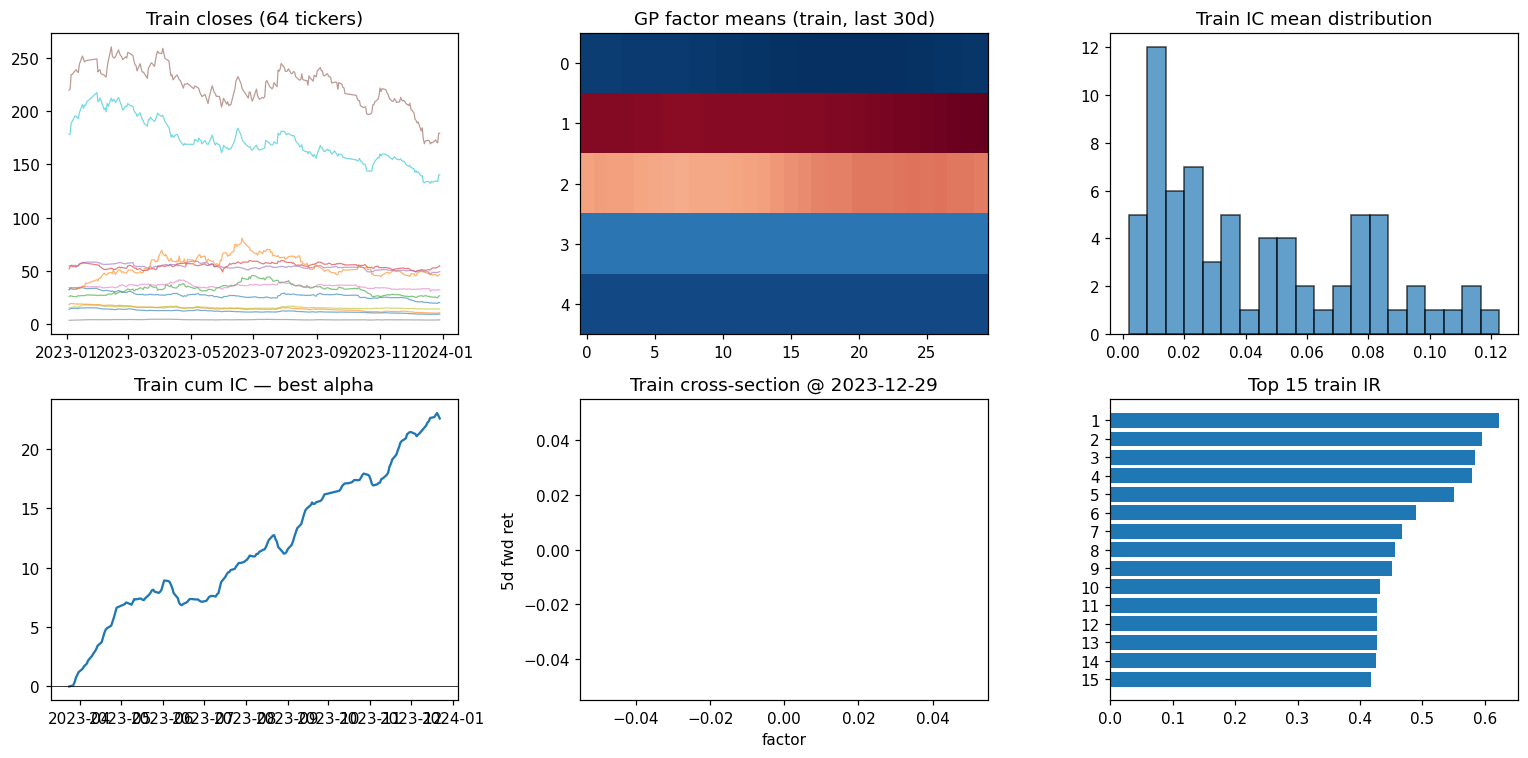

Done (in-sample).


In [11]:
# ── Step 5: In-sample charts (train window) ──
show_n = min(5, len(discovered))
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

ax = axes[0]
for sym in list(close_train.columns)[:12]:
    ax.plot(close_train.index, close_train[sym], alpha=0.6, linewidth=0.8)
ax.set_title(f"Train closes ({close_train.shape[1]} tickers)")

if show_n:
    heat = pd.concat({f"a{i}": factors[i].iloc[-30:].mean(axis=1) for i in range(1, show_n+1)}, axis=1)
    axes[1].imshow(heat.T, aspect="auto", cmap="RdBu_r")
    axes[1].set_title("GP factor means (train, last 30d)")

axes[2].hist(catalog["ic_mean"], bins=20, edgecolor="k", alpha=0.7)
axes[2].set_title("Train IC mean distribution")

if discovered:
    ic = daily_ic(discovered[0].values, fwd_train)
    axes[3].plot(ic.index, ic.cumsum())
    axes[3].set_title("Train cum IC — best alpha")
    axes[3].axhline(0, color="k", lw=0.5)

if discovered:
    dt = discovered[0].values.dropna(how="all").index[-1]
    axes[4].scatter(discovered[0].values.loc[dt], fwd_train.loc[dt], alpha=0.7)
    axes[4].set_xlabel("factor")
    axes[4].set_ylabel("5d fwd ret")
    axes[4].set_title(f"Train cross-section @ {dt.date()}")

top = catalog.nlargest(15, "ir")
axes[5].barh(top["alpha_id"].astype(str), top["ir"])
axes[5].set_title("Top 15 train IR")
axes[5].invert_yaxis()

plt.tight_layout()
plt.show()
print("Done (in-sample).")


In [12]:
# ── Step 6: Out-of-sample evaluation ──
print(f"OOS window: {close_test.index[0].date()} → {close_test.index[-1].date()}")
t0 = time.time()
oos_rows = []
for i, sc in enumerate(discovered, 1):
    row = oos_score(sc, panel_test, fwd_test)
    if row:
        row["alpha_id"] = i
        oos_rows.append(row)
oos_df = pd.DataFrame(oos_rows)
effective_oos = pd.DataFrame()
if oos_df.empty:
    print("No factors produced valid OOS scores — check test window length.")
else:
    oos_df = oos_df.sort_values("oos_ir", ascending=False).reset_index(drop=True)
    effective_oos = oos_df[
        (oos_df["is_ir"] > 0.20) &
        (oos_df["oos_ir"] >= OOS_MIN_IR) &
        (oos_df["oos_ic_mean"] > OOS_MIN_IC) &
        (oos_df["ir_decay"] >= OOS_IR_DECAY_MIN)
    ].copy()
    print(f"Scored {len(oos_df)} factors in {time.time()-t0:.1f}s")
    print(f"Effective OOS: {len(effective_oos)} / {len(oos_df)} pass filters")
    print(f"  (oos_ir≥{OOS_MIN_IR}, oos_ic>0, ir_decay≥{OOS_IR_DECAY_MIN})")
    display(oos_df.head(15))
    if len(effective_oos):
        print("\nTop effective OOS factors:")
        display(effective_oos.head(15))


OOS window: 2024-01-02 → 2024-06-28
Scored 69 factors in 3.3s
Effective OOS: 26 / 69 pass filters
  (oos_ir≥0.1, oos_ic>0, ir_decay≥0.4)


,formula,is_ic_mean,is_ir,is_hit_rate,oos_ic_mean,oos_ir,oos_hit_rate,oos_n_days,ir_decay,complexity,alpha_id
0,"delay(mean(mean(std(delay(max(range_pct,10),20...",0.051106,0.267353,0.566667,0.221152,1.744256,0.920000,25,6.524165,7,27
1,"delay(delay(sum(min(body_pct,15),8),3),20)",0.074643,0.351331,0.668394,0.143355,0.682735,0.750000,68,1.943285,5,19
2,"delay(log(max(mean(std(max(ret,5),6),15),10)),20)",0.105658,0.595316,0.744565,0.131125,0.675491,0.766667,60,1.134675,7,2
3,"delay(log(std(sum(max(ret,5),8),8)),20)",0.079661,0.427394,0.646465,0.121975,0.609400,0.675676,74,1.425853,6,12
4,"delay(mean(mean(pressure,15),20),20)",0.047185,0.191377,0.581522,0.142274,0.609107,0.661017,59,3.182760,4,36
5,delay((mean(delay(sum(delay(sum(max(min(delay(...,0.082884,0.456028,0.681564,0.064351,0.543207,0.629630,54,1.191171,13,8
6,"delay(delay(std(sum(range_pct,8),6),3),20)",0.048616,0.280211,0.608911,0.098951,0.534271,0.701299,77,1.906675,5,24
7,"delay(sum(sum(min(delay(range_pct,10),15),8),8...",0.122803,0.622124,0.771739,0.099794,0.474950,0.627119,59,0.763433,6,1
8,"corr(volume,body_pct,20)",0.007500,0.047600,0.481651,0.075455,0.439625,0.763441,93,9.235872,3,64
9,"(sum(std(pressure,10),8)*log(std(ret,6)))",0.041328,0.247400,0.615385,0.062491,0.435783,0.656250,96,1.761446,7,30



Top effective OOS factors:


,formula,is_ic_mean,is_ir,is_hit_rate,oos_ic_mean,oos_ir,oos_hit_rate,oos_n_days,ir_decay,complexity,alpha_id
0,"delay(mean(mean(std(delay(max(range_pct,10),20...",0.051106,0.267353,0.566667,0.221152,1.744256,0.920000,25,6.524165,7,27
1,"delay(delay(sum(min(body_pct,15),8),3),20)",0.074643,0.351331,0.668394,0.143355,0.682735,0.750000,68,1.943285,5,19
2,"delay(log(max(mean(std(max(ret,5),6),15),10)),20)",0.105658,0.595316,0.744565,0.131125,0.675491,0.766667,60,1.134675,7,2
3,"delay(log(std(sum(max(ret,5),8),8)),20)",0.079661,0.427394,0.646465,0.121975,0.609400,0.675676,74,1.425853,6,12
5,delay((mean(delay(sum(delay(sum(max(min(delay(...,0.082884,0.456028,0.681564,0.064351,0.543207,0.629630,54,1.191171,13,8
6,"delay(delay(std(sum(range_pct,8),6),3),20)",0.048616,0.280211,0.608911,0.098951,0.534271,0.701299,77,1.906675,5,24
7,"delay(sum(sum(min(delay(range_pct,10),15),8),8...",0.122803,0.622124,0.771739,0.099794,0.474950,0.627119,59,0.763433,6,1
9,"(sum(std(pressure,10),8)*log(std(ret,6)))",0.041328,0.247400,0.615385,0.062491,0.435783,0.656250,96,1.761446,7,30
10,delay((mean(delay(sum(delay(sum(log(max(mean(s...,0.059593,0.336385,0.633721,0.086695,0.416686,0.687500,48,1.238718,14,22
11,"((rank(low)*log(pressure))*sum(min(-(std(ret,1...",0.074426,0.279707,0.639344,0.119627,0.413430,0.711111,45,1.478080,11,25


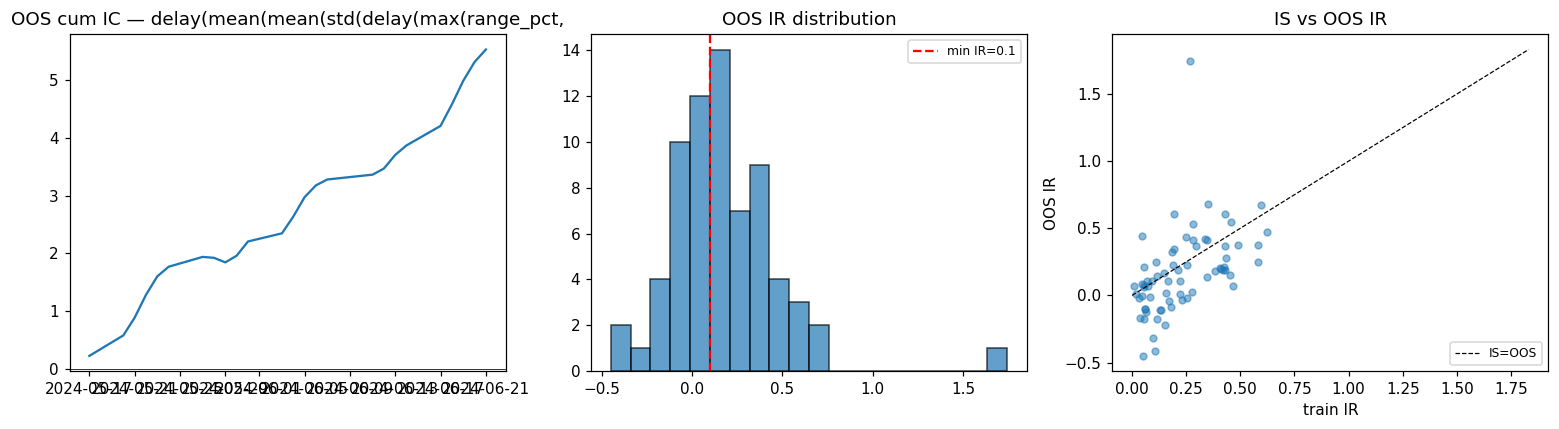

Done — nothing saved to disk.


In [13]:
# ── Step 7: OOS charts ──
if "oos_df" in dir() and not oos_df.empty and len(effective_oos):
    best_formula = effective_oos.iloc[0]["formula"]
    best_sc = next(sc for sc in discovered if sc.formula == best_formula)
    vals_oos = eval_expr(best_sc.expr, panel_test) * best_sc.sign
    ic_oos = daily_ic(vals_oos, fwd_test)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(ic_oos.index, ic_oos.cumsum(), color="C0")
    axes[0].axhline(0, color="k", lw=0.5)
    axes[0].set_title(f"OOS cum IC — {best_formula[:40]}")

    axes[1].hist(oos_df["oos_ir"], bins=20, edgecolor="k", alpha=0.7)
    axes[1].axvline(OOS_MIN_IR, color="r", ls="--", label=f"min IR={OOS_MIN_IR}")
    axes[1].set_title("OOS IR distribution")
    axes[1].legend(fontsize=8)

    axes[2].scatter(oos_df["is_ir"], oos_df["oos_ir"], alpha=0.5, s=20)
    lim = max(oos_df["is_ir"].max(), oos_df["oos_ir"].max()) * 1.05
    axes[2].plot([0, lim], [0, lim], "k--", lw=0.8, label="IS=OOS")
    axes[2].set_xlabel("train IR")
    axes[2].set_ylabel("OOS IR")
    axes[2].set_title("IS vs OOS IR")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("Skip OOS charts — no effective factors passed filters.")
print("Done — nothing saved to disk.")


## Summary

| Step | What | ~Time |
|------|------|-------|
| 1 | Load OpenBB + train/test split | 2–5 min |
| 2 | GP evolve on **train** window | 1–15 min |
| 3–4 | Select 191 + in-sample catalog | 1–20 min |
| 5 | In-sample charts | < 10 s |
| 6–7 | **OOS evaluation** + charts | < 1 min |

**Train/OOS split:** GP uses dates ≤ `TRAIN_END`; OOS tests dates ≥ `TEST_START`.

**Effective factors:** dedupe by correlation, rank by composite score, then filter on `oos_ir`, `oos_ic_mean`, and `ir_decay`.

Set `DATA_PROVIDER = "synthetic"` for offline testing.
